# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [4]:
# Install Package 
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
import math


# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [5]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head()
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

#

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),...,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,...,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17-Oct-24


In [6]:
data.shape

(3702, 44)

In [7]:
# Examine categorical data from Fuel Type column
manufacturer_types = data["Manufacturer"].unique()
print(f"Unique fuel types: {manufacturer_types}")
print(f"Number of categories: {len(manufacturer_types)}")

Unique fuel types: ['ABARTH' 'ALFA ROMEO' 'ALPINE' 'ASTON MARTIN LAGONDA' 'BENTLEY MOTORS'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER JEEP' 'CITROEN' 'DACIA' 'DS' 'FERRARI'
 'FIAT' 'FORD' 'GENESIS' 'GWM' 'HONDA' 'HYUNDAI' 'INEOS Automotive Ltd'
 'KGM UK Motors Ltd' 'KIA' 'LEXUS' 'LOTUS' 'MASERATI' 'MAZDA' 'McLaren'
 'MERCEDES-BENZ' 'MG MOTORS UK' 'MORGAN MOTOR COMPANY' 'NISSAN' 'PEUGEOT'
 'PORSCHE' 'RENAULT' 'Rolls Royce' 'SEAT' 'Smart UK Automotive Ltd'
 'SUBARU' 'SUZUKI' 'TESLA' 'TOYOTA' 'VAUXHALL' 'VOLVO' 'XPENG']
Number of categories: 43


In [8]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [9]:
# Count the number of N/A values in each column
def count_na(data):
    number_of_columns = data.shape[1]
    for i in range(number_of_columns):
        col_name = data.columns[i]
        count = data[col_name].isna().sum()
        print(f"The number of NA values in column '{col_name}' is {count}")
count_na(data)

The number of NA values in column 'Manufacturer' is 0
The number of NA values in column 'Model' is 0
The number of NA values in column 'Description' is 0
The number of NA values in column 'Transmission' is 558
The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 2
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 19
The number of NA values in column 'Engine Power (Kw)' is 8
The number of NA values in column 'Electric energy consumption Miles/kWh' is 883
The number of NA values in column 'wh/km' is 2516
The number of NA values in column 'Maximum range (Km)' is 2375
The number of NA values in column 'Maximum range (Miles)' is 2702
The number of NA values in column 'Euro Standard' is 0
The number of NA values in column 'Diesel VED Supplement' is 0
The number of NA values in column 'Testing Scheme' is 0
The number of NA

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']


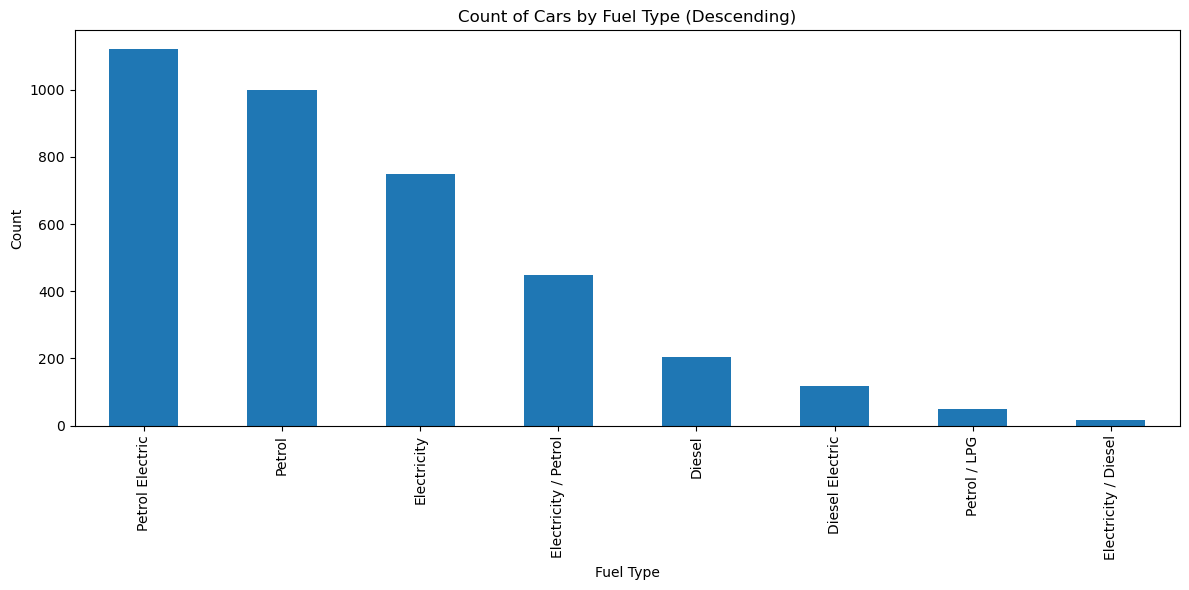

In [10]:
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")

fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Average NOx Emissions by Fuel Type')

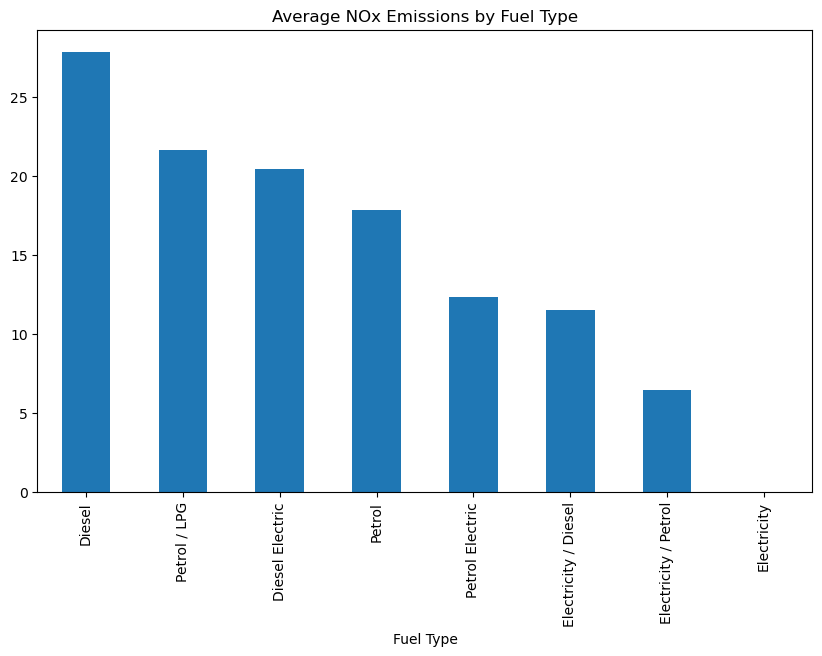

In [11]:
data.groupby("Fuel Type")["Emissions NOx [mg/km]"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,6))
plt.title("Average NOx Emissions by Fuel Type")

Correlation between Engine Capacity and Emissions NOx: 0.002769031929153689


/var/folders/9z/h5wxsfgs1v9dg0bx0m5jvd0r0000gn/T/ipykernel_63174/2217262933.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')


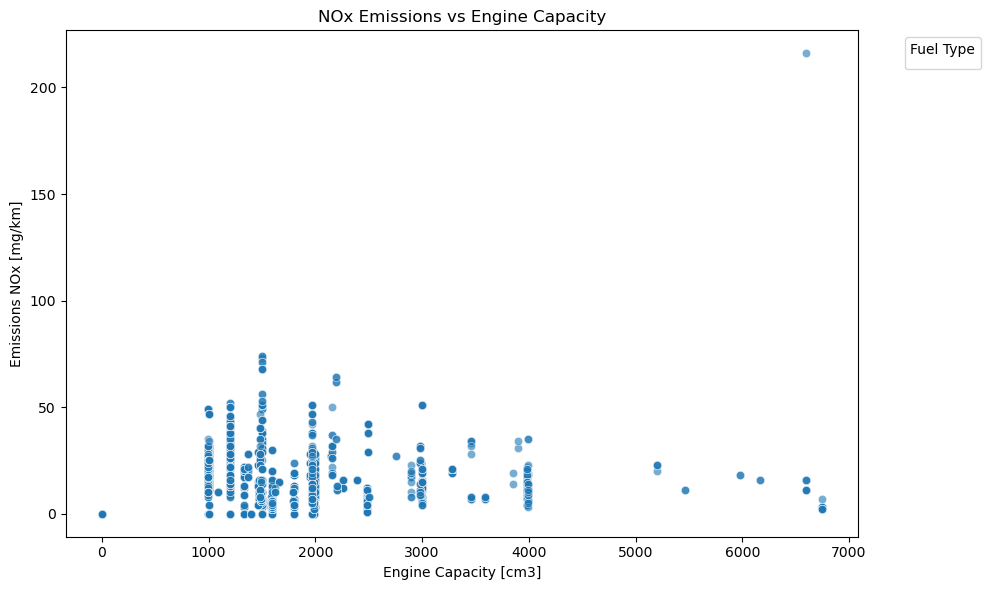

In [12]:
# Examine relationships between NOx emissions and engine capacity
correlation = data["Engine Capacity"].corr(data["Emissions NOx [mg/km]"])
print(f"Correlation between Engine Capacity and Emissions NOx: {correlation}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="Engine Capacity", y="Emissions NOx [mg/km]", alpha=0.6)
plt.title("NOx Emissions vs Engine Capacity")
plt.xlabel("Engine Capacity [cm3]")
plt.ylabel("Emissions NOx [mg/km]")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

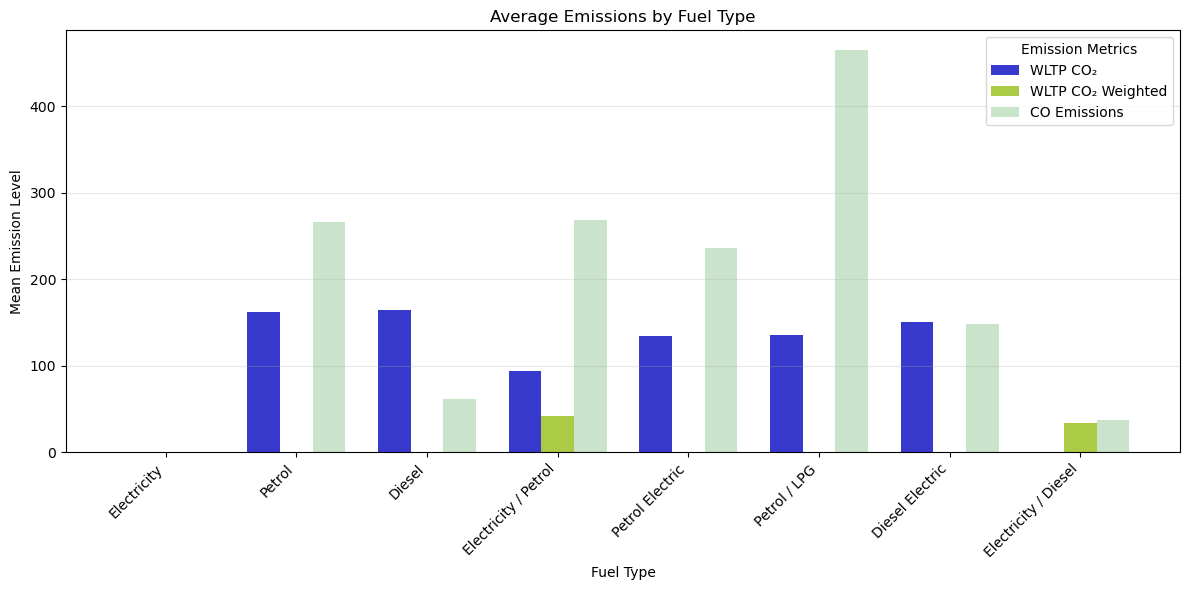

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1. Compute mean emissions per fuel type
metrics = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
emission_means = data.groupby("Fuel Type")[metrics].mean().reindex(fuel_type_categories)

# Step 2. Plot grouped bar chart
x = np.arange(len(emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar

plt.figure(figsize=(12, 6))

plt.bar(x - width, emission_means["WLTP CO2"], width, label="WLTP CO₂", color="#3639CC")
plt.bar(x, emission_means["WLTP CO2 Weighted"], width, label="WLTP CO₂ Weighted", color="#ABCA45")
plt.bar(x + width, emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")

plt.xticks(x, emission_means.index, rotation=45, ha='right')
plt.title("Average Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Mean Emission Level")
plt.legend(title="Emission Metrics")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion**
Pick WLTP CO2 due to: 
- have enough data accross different fuel types. (Despite CO emissions have more, but not common as CO2)
- WLTP CO2 (wegihts) is excluded because it lacked data distrbution accorss fuel types. 
- CO2 is more common to people understanding about gas emissions. 

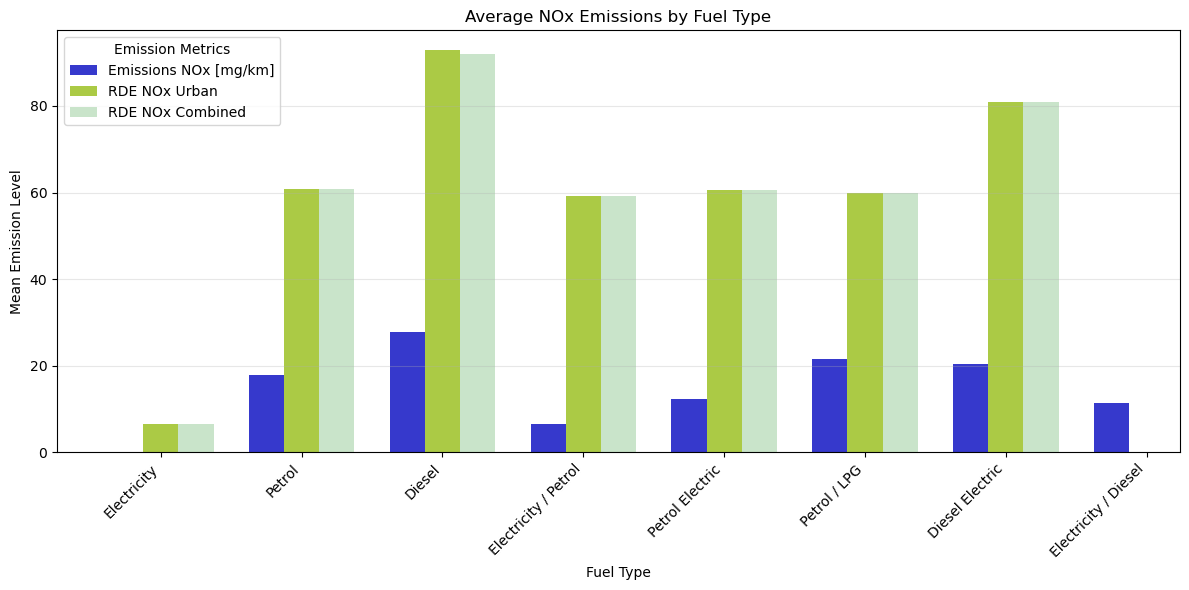

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1. Compute mean emissions per fuel type
metrics = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
emission_means = data.groupby("Fuel Type")[metrics].mean().reindex(fuel_type_categories)

# Step 2. Plot grouped bar chart
x = np.arange(len(emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar

plt.figure(figsize=(12, 6))

plt.bar(x - width, emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
plt.bar(x, emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
plt.bar(x + width, emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")

plt.xticks(x, emission_means.index, rotation=45, ha='right')
plt.title("Average NOx Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Mean Emission Level")
plt.legend(title="Emission Metrics")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Pick Emissions NOx [mg/km] because: 
- has difference mean across fuel type -> easier for comparison and prediction afterward.
- RDE NOx Urban and RDE NOx combined are nearly equal across different fuel types. Their mean values are not much different across fuel types. 

Based on the two graphs, eletric cars have no CO2 emissions, and low NOx emissions as well (given the source state that NOx emissions from eletric car are from their battery). Therefore, all of the eletric cars will be excluded from the datasets. 
Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid).
Furthermore, since the target variables (WLTP CO2 and NO emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid

In [15]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


Based on the visualisation, following variables should be moved since they are not relevant


In [16]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change",
]
data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape after removing columns: (3702, 19)


In [17]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


In [32]:
# Examine splitted datasets
print(data_fuel.shape)
print(data_fuel.head())
print("\n")
print(data_hybrid.shape)
print(data_hybrid.head())


(1250, 19)
  Manual or Automatic  Engine Capacity Fuel Type  \
4              Manual           1368.0    Petrol   
5              Manual           1368.0    Petrol   
6              Manual           1368.0    Petrol   
7              Manual           1368.0    Petrol   
8              Manual           1368.0    Petrol   

                         Powertrain  Engine Power (PS)  WLTP Imperial Low  \
4  Internal Combustion Engine (ICE)              165.0               28.8   
5  Internal Combustion Engine (ICE)              165.0               27.8   
6  Internal Combustion Engine (ICE)              165.0               28.8   
7  Internal Combustion Engine (ICE)              165.0               27.8   
8  Internal Combustion Engine (ICE)              179.0               26.9   

   WLTP Imperial Medium  WLTP Imperial High  WLTP Imperial Extra High  \
4                  43.3                47.0                      47.0   
5                  42.1                45.5                      38

In [19]:
count_na(data_fuel)

The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 0
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 0
The number of NA values in column 'WLTP Imperial Low' is 0
The number of NA values in column 'WLTP Imperial Medium' is 0
The number of NA values in column 'WLTP Imperial High' is 0
The number of NA values in column 'WLTP Imperial Extra High' is 0
The number of NA values in column 'WLTP Imperial Combined' is 0
The number of NA values in column 'WLTP Imperial Combined (Weighted)' is 17
The number of NA values in column 'WLTP Metric Low' is 0
The number of NA values in column 'WLTP Metric Medium' is 0
The number of NA values in column 'WLTP Metric High' is 0
The number of NA values in column 'WLTP Metric Extra High' is 0
The number of NA values in column 'WLTP Metric Combined' is 0
The number of NA values in colum

In [20]:
count_na(data_hybrid)

The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 0
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 0
The number of NA values in column 'WLTP Imperial Low' is 0
The number of NA values in column 'WLTP Imperial Medium' is 0
The number of NA values in column 'WLTP Imperial High' is 0
The number of NA values in column 'WLTP Imperial Extra High' is 0
The number of NA values in column 'WLTP Imperial Combined' is 0
The number of NA values in column 'WLTP Imperial Combined (Weighted)' is 3
The number of NA values in column 'WLTP Metric Low' is 0
The number of NA values in column 'WLTP Metric Medium' is 0
The number of NA values in column 'WLTP Metric High' is 0
The number of NA values in column 'WLTP Metric Extra High' is 0
The number of NA values in column 'WLTP Metric Combined' is 0
The number of NA values in column

### Statistical Analysis

In [21]:
# Review Mean, Min, Max, SD of data
data.describe()

,Engine Capacity,Engine Power (PS),WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,WLTP Imperial Extra High,WLTP Imperial Combined,WLTP Imperial Combined (Weighted),WLTP Metric Low,WLTP Metric Medium,WLTP Metric High,WLTP Metric Extra High,WLTP Metric Combined,WLTP Metric Combined (Weighted),WLTP CO2,Emissions NOx [mg/km]
count,3700.000000,3683.000000,3702.000000,3702.000000,3702.000000,3702.000000,3702.000000,3682.000000,3702.000000,3702.000000,3702.000000,3702.000000,3702.000000,3692.000000,3702.000000,3060.000000
mean,1457.020000,202.254141,29.834414,36.915073,39.302728,31.392410,33.833928,27.268278,6.006213,4.568531,4.219908,5.177120,4.832442,0.242389,111.426526,14.306536
std,1039.860432,127.951896,21.940253,24.854016,25.423989,19.924507,22.184043,80.867074,5.602868,3.344553,3.137791,3.608788,3.482866,0.917002,76.228559,12.533870
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,999.000000,129.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
50%,1490.000000,160.000000,34.400000,44.800000,50.400000,40.400000,43.300000,0.000000,6.700000,5.200000,4.800000,6.100000,5.600000,0.000000,129.000000,12.000000
75%,1993.000000,244.000000,42.200000,53.300000,57.600000,46.300000,49.600000,0.000000,8.000000,6.200000,5.600000,6.900000,6.500000,0.000000,148.000000,21.000000
max,6749.000000,1267.000000,100.900000,97.400000,80.700000,68.900000,74.300000,706.300000,193.000000,28.200000,32.500000,42.200000,42.800000,12.400000,380.000000,216.000000


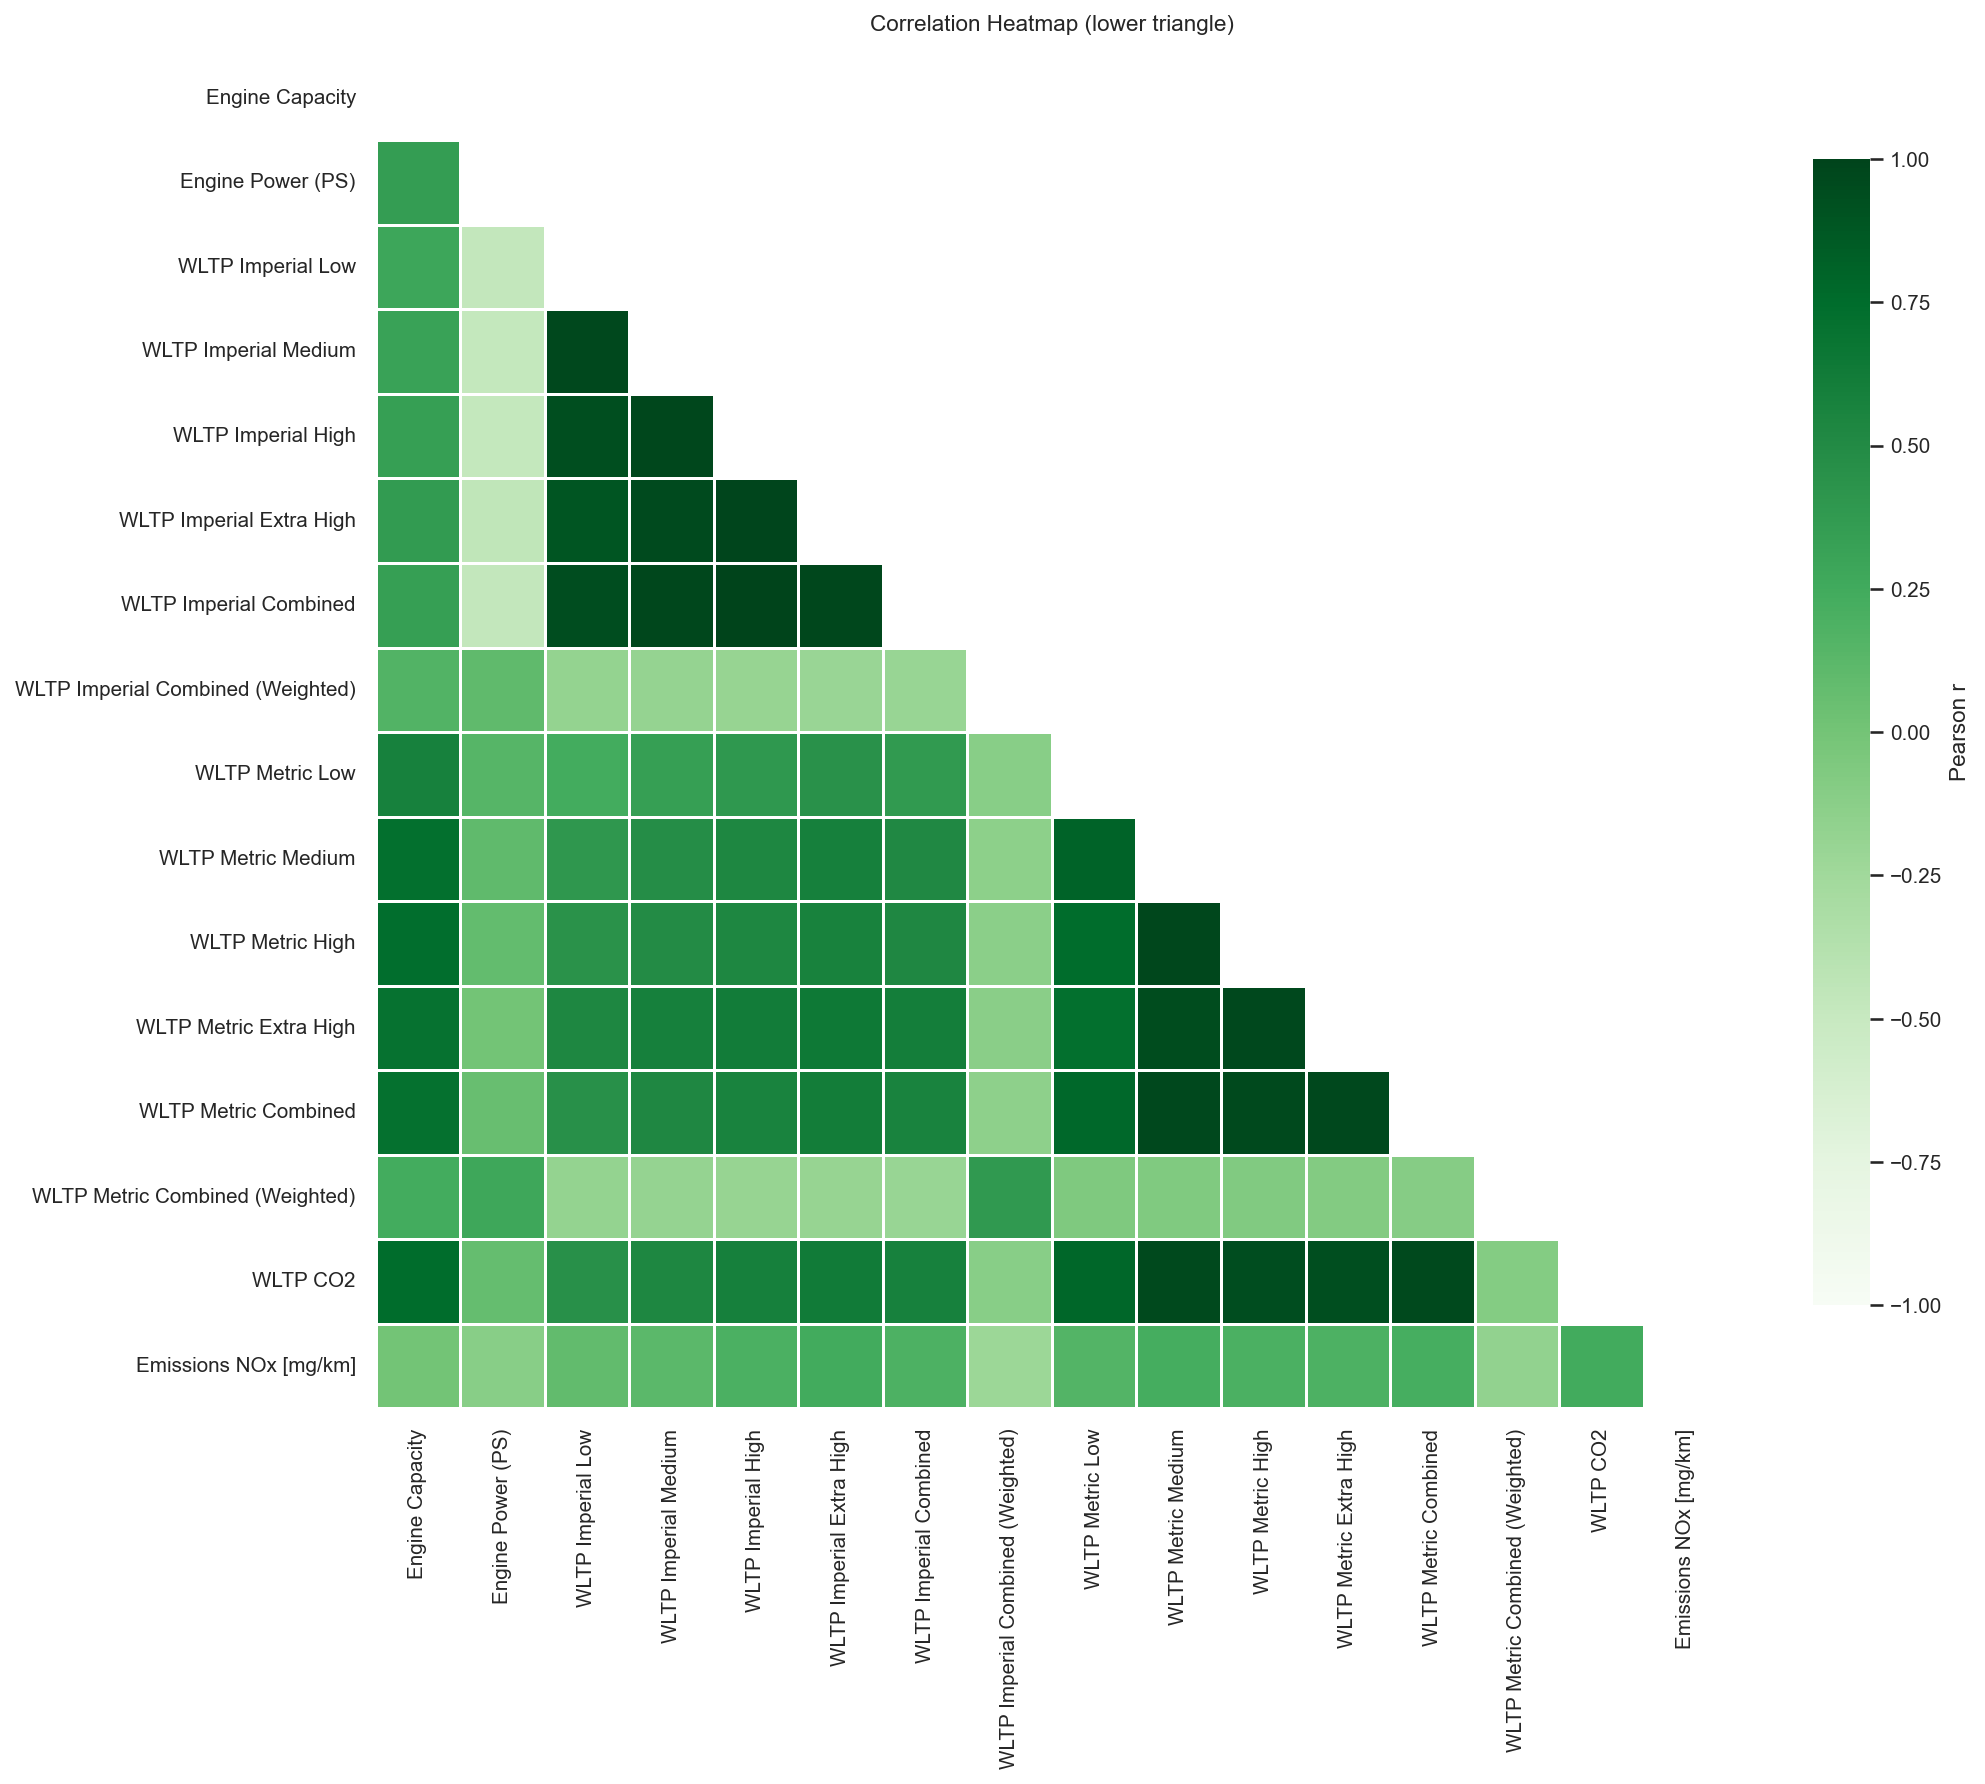

In [22]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", pad=12)
plt.tight_layout()
plt.show()

Since it is over detailed to visualise the correlation matrix of all variables, only top 20 will be visualised to examine their correlations.

In [23]:
# -- Correlation Analysis for NOx Emissions of Fuel Cars --
def plot_nox_correlation(variable, data_fuel):
    # Set the target variable 
    target = variable.string()

    # numeric-only correlation
    corr = data_fuel.select_dtypes(include='number').corr()

    # Extract correlations with target
    target_corr = corr[target].drop(labels=[target])

    # Sort by absolute correlation and take top 20
    top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

    # Plot
    plt.figure(figsize=(8, 7), dpi=150)
    bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

    # Add correlation values on bars
    for bar, value in zip(bars, top20.values):
        plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
                ha='left' if value > 0 else 'right', va='center', fontsize=9)

    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top 20 Correlations with {target}", fontsize=13, pad=10)
    plt.xlabel("Correlation - Pearson r", fontsize=11)
    plt.ylabel("Variable", fontsize=11)
    plt.gca().invert_yaxis()  # highest correlation on top
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

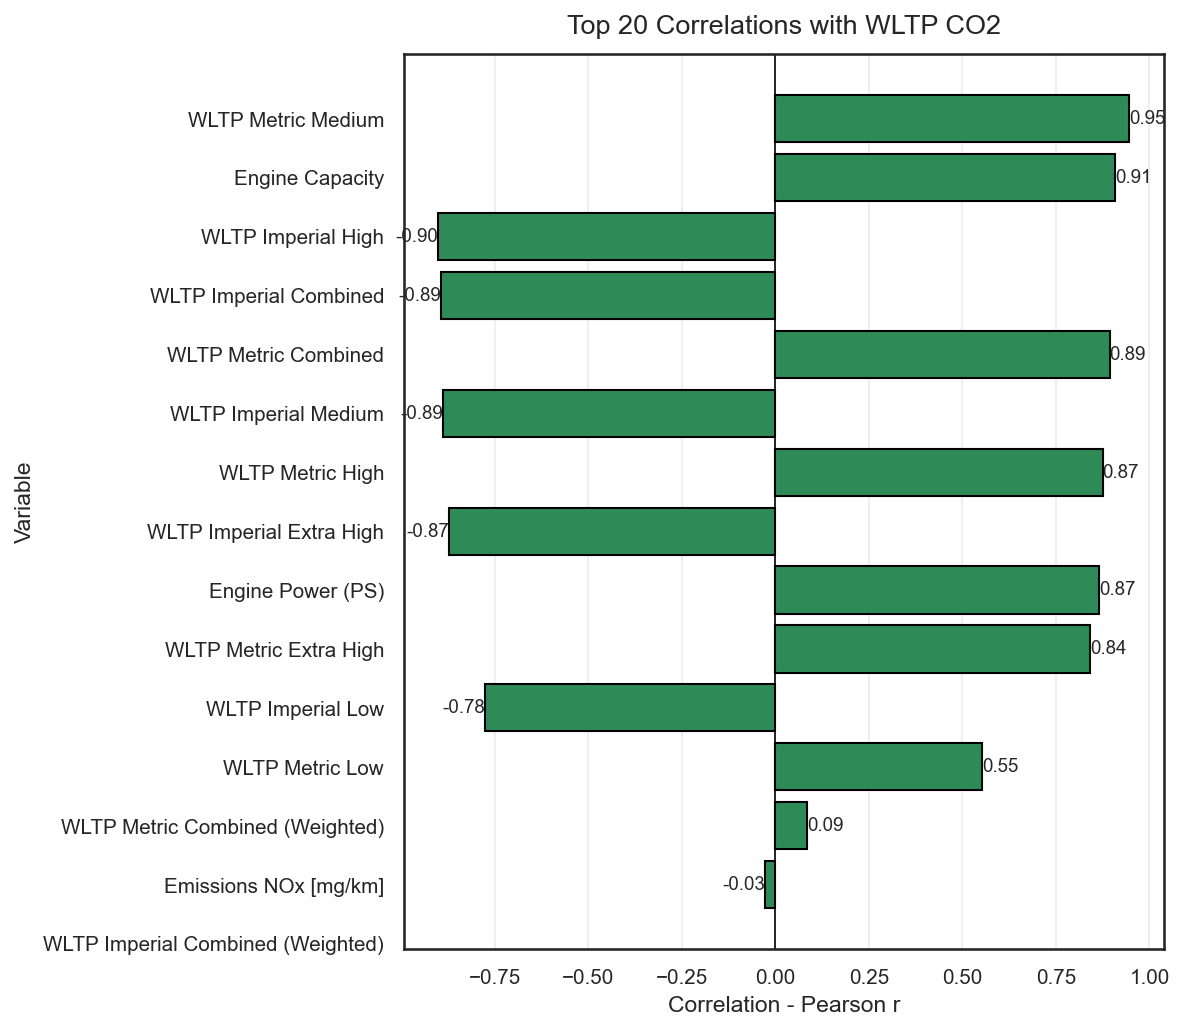

In [24]:
# -- Correlation Analysis for WLTP CO2 - Hybrid Cars --

# Set the target variable
target = "WLTP CO2"

corr = data_fuel.select_dtypes(include='number').corr()

# Extract correlations with target
target_corr = corr[target].drop(labels=[target])

# Sort by absolute correlation and take top 20
top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

# Plot
plt.figure(figsize=(8, 7), dpi=150)
bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

# Add correlation values on bars
for bar, value in zip(bars, top20.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
             ha='left' if value > 0 else 'right', va='center', fontsize=9)

plt.axvline(0, color='black', linewidth=0.8)
plt.title(f"Top 20 Correlations with {target}", fontsize=13, pad=10)
plt.xlabel("Correlation - Pearson r", fontsize=11)
plt.ylabel("Variable", fontsize=11)
plt.gca().invert_yaxis()  # highest correlation on top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

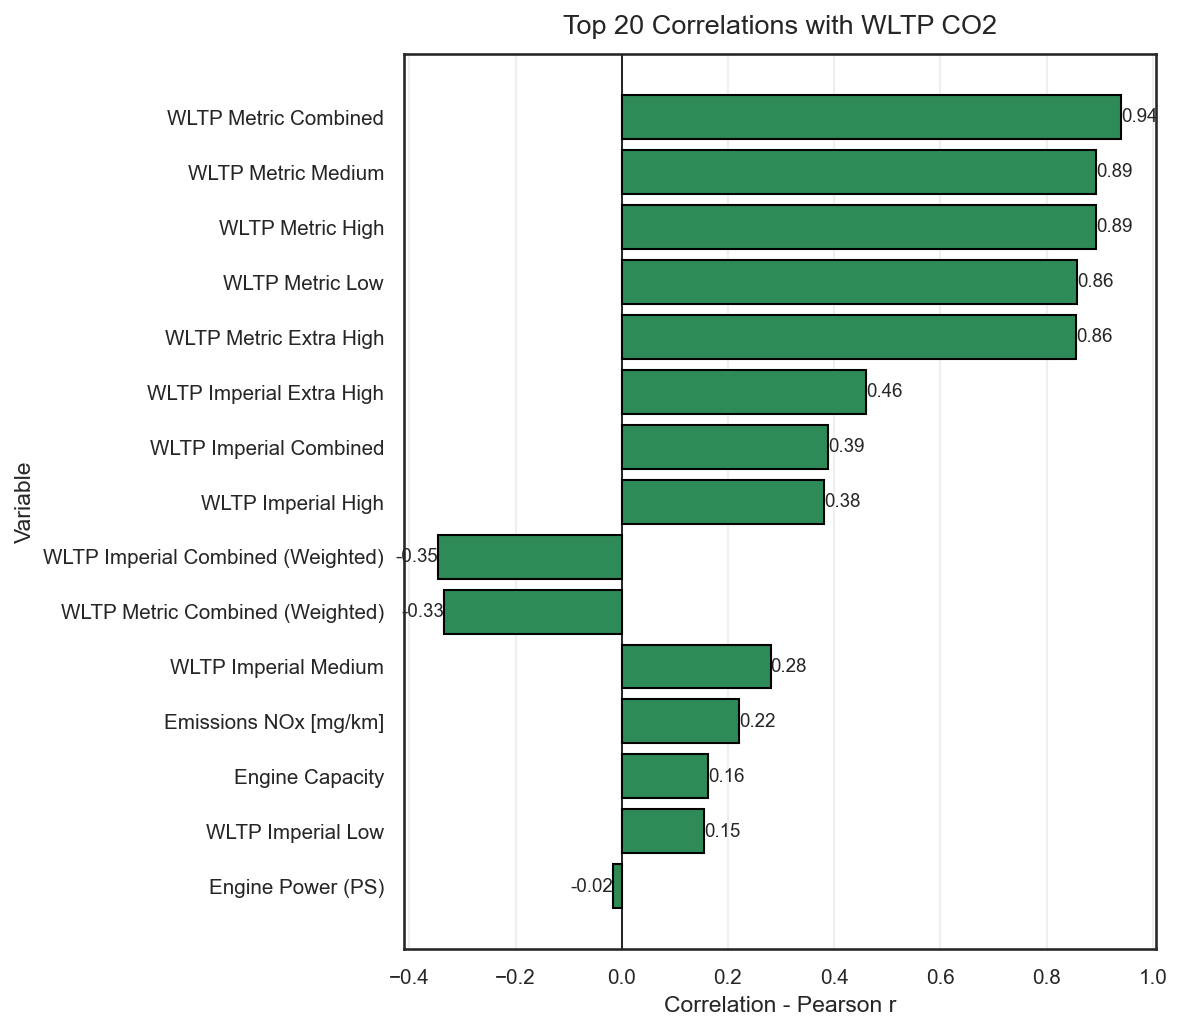

In [25]:
# -- Correlation Analysis for WLTP CO2 - Hybrid Cars --

# Set the target variable
target = "WLTP CO2"

# numeric-only correlation
corr = data_hybrid.select_dtypes(include='number').corr()

# Extract correlations with target
target_corr = corr[target].drop(labels=[target])

# Sort by absolute correlation and take top 20
top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

# Plot
plt.figure(figsize=(8, 7), dpi=150)
bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

# Add correlation values on bars
for bar, value in zip(bars, top20.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
             ha='left' if value > 0 else 'right', va='center', fontsize=9)

plt.axvline(0, color='black', linewidth=0.8)
plt.title(f"Top 20 Correlations with {target}", fontsize=13, pad=10)
plt.xlabel("Correlation - Pearson r", fontsize=11)
plt.ylabel("Variable", fontsize=11)
plt.gca().invert_yaxis()  # highest correlation on top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# # -- Optional idea: automate histogram plotting seperately for all numeric columns

# ## arguments are the column name (string) and the dataframe.
# def plot_numeric_histogram(column_name, df):
    
#     if column_name not in df.columns:
#         print(f" Column '{column_name}' is not found in dataset.")
#         return
    
#     if not pd.api.types.is_numeric_dtype(df[column_name]):
#         print(f" Column '{column_name}' is not numeric. Please select a numeric variable.")
#         return

#     plt.figure(figsize=(8, 5))
#     plt.hist(df[column_name].dropna(), bins=15)
#     plt.title(f"Histogram of {column_name}", fontsize=14)
#     plt.xlabel(column_name)
#     plt.ylabel("Frequency")
#     plt.grid(alpha=0.3)
#     plt.show()

# # Examine histogram for target variables:
# plot_numeric_histogram("Emissions NOx [mg/km]", data)
# plot_numeric_histogram("WLTP CO2", data)

# # Visualise all numeric columns in a histogram matrix
# number_of_columns = data_fuel.shape[1]

# for i in range(number_of_columns):
#     col_name = data.columns[i]
#     plot_numeric_histogram(col_name, data)

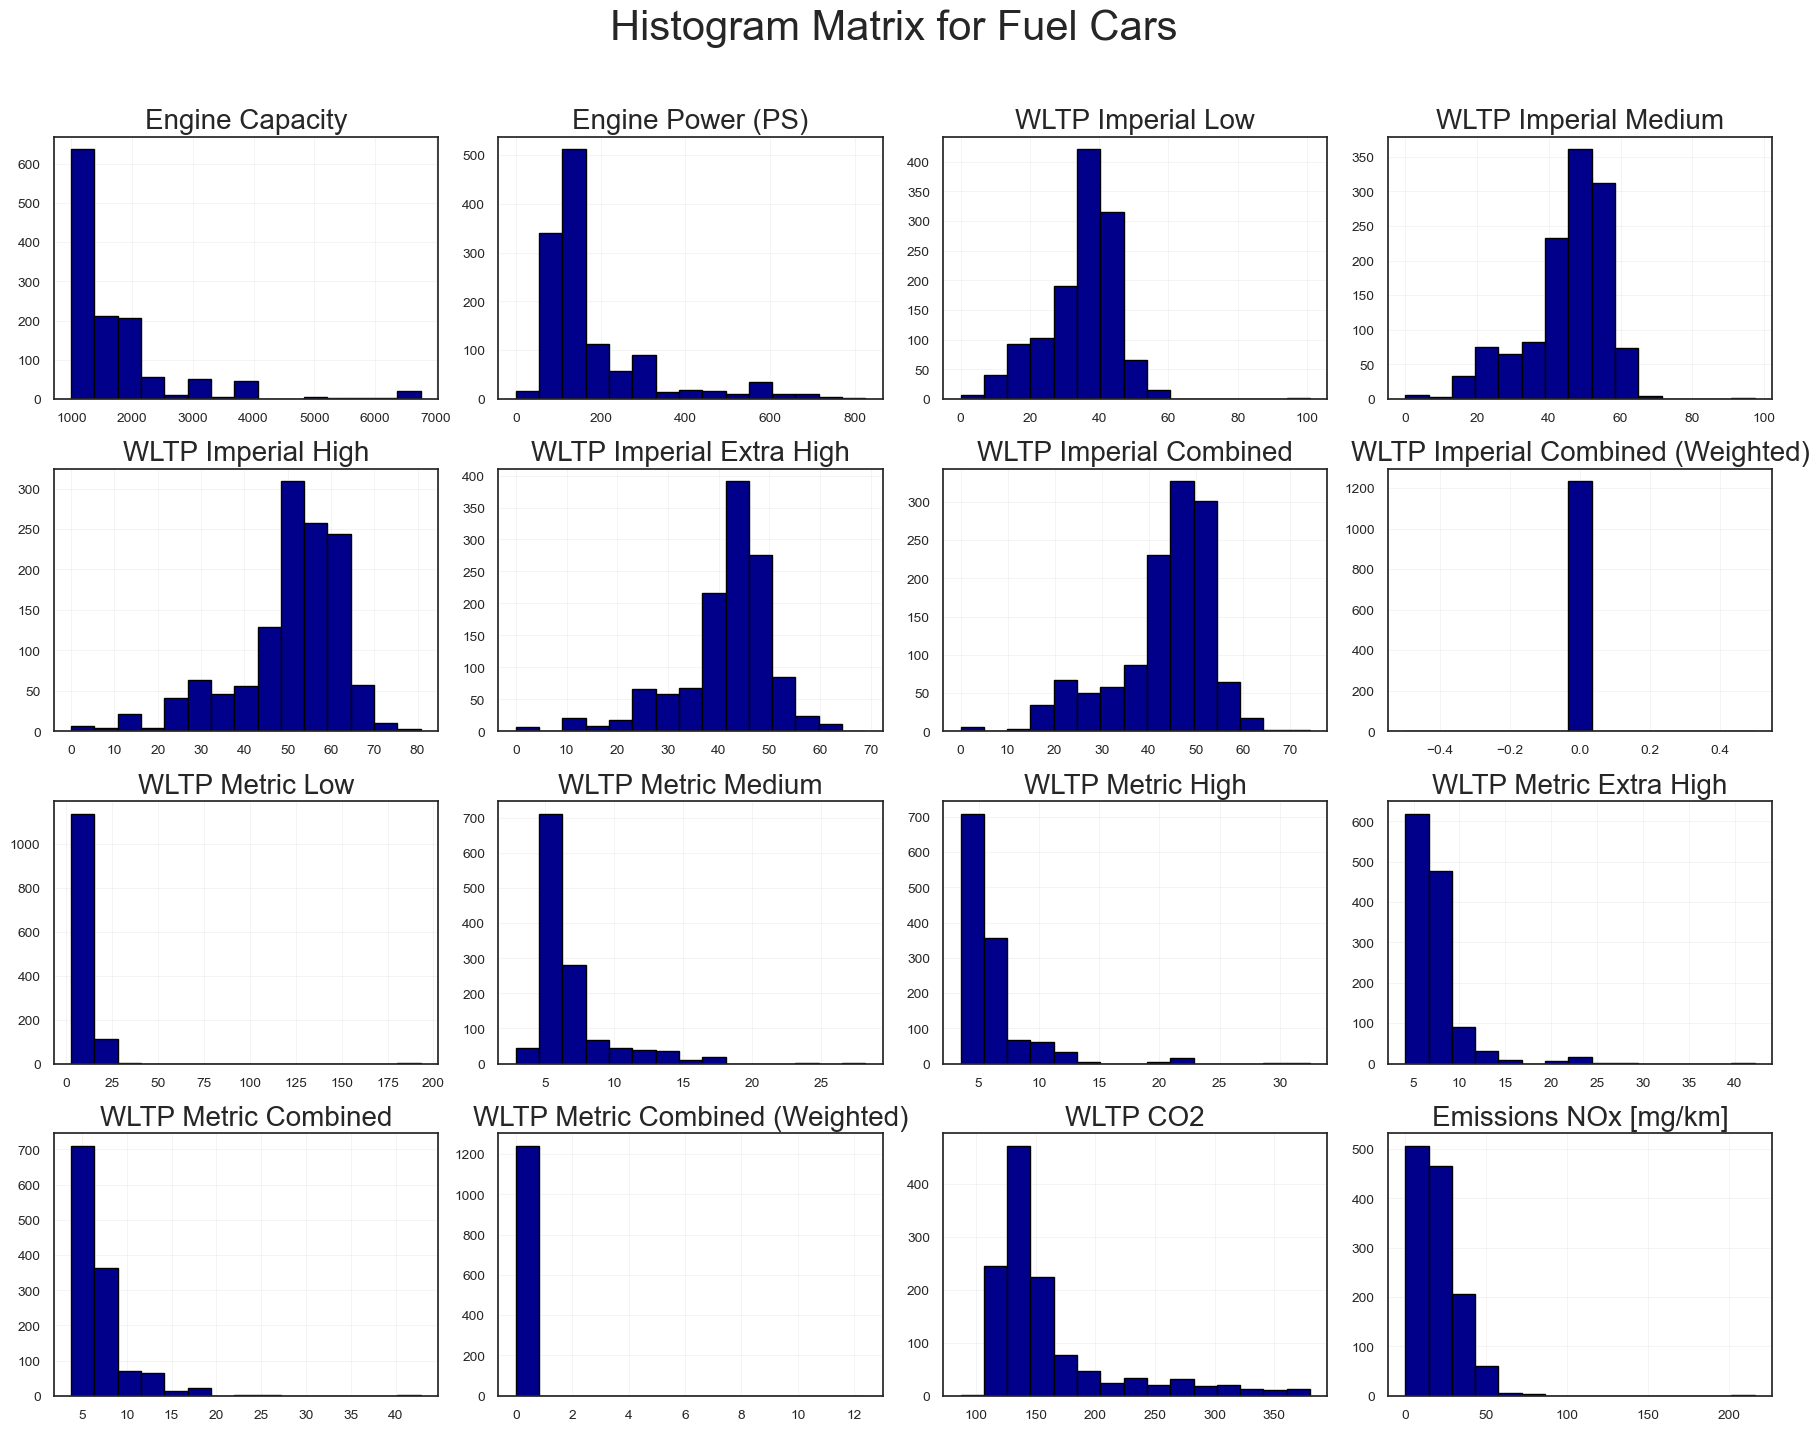

In [27]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()


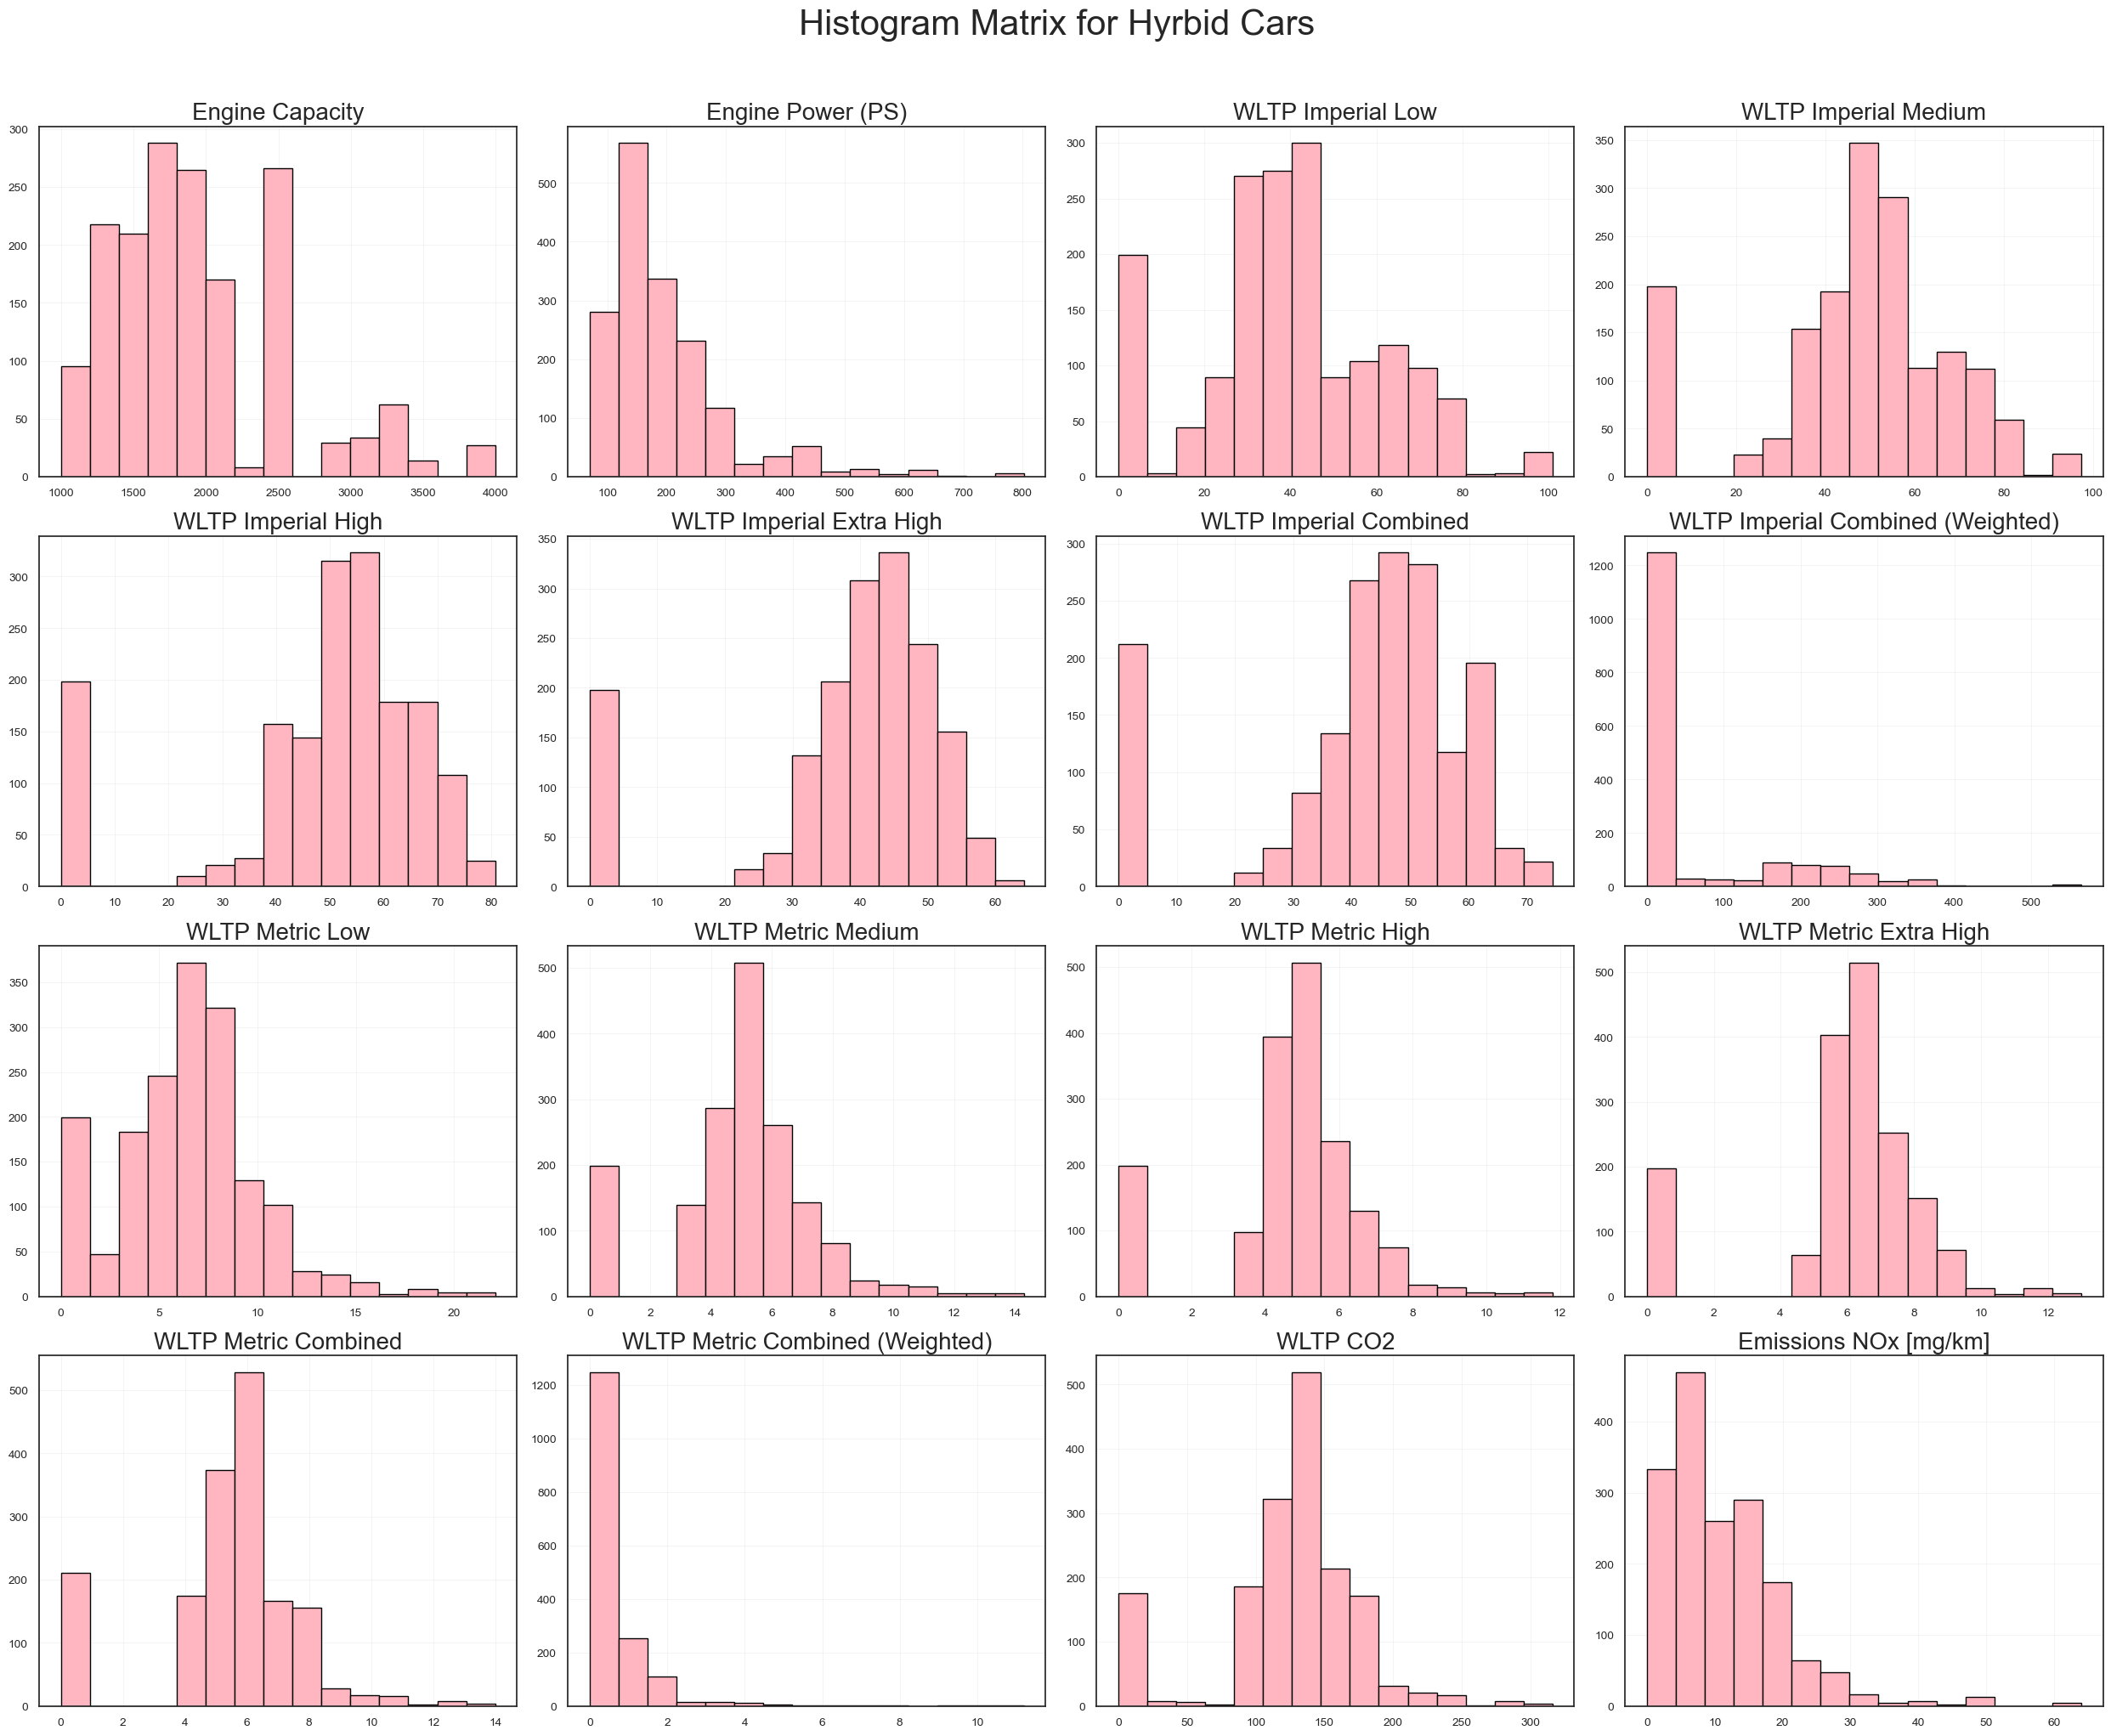

In [30]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(25,20),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

Here are some steps for statistical analysis with your dataset:

1. **Descriptive Statistics**:  
    Use `data.describe()` to get mean, median, std, min, max, and quartiles for numerical columns.

2. **Missing Data Analysis**:  
    Check missing values with `data.isnull().sum()`. Decide on imputation or removal.

3. **Correlation Analysis**:  
    Use `data.corr()` to find relationships between variables. Visualize with a heatmap (already done).

4. **Distribution Analysis**:  
    Plot histograms or boxplots for key variables to check their distributions and outliers.

5. **Group Comparisons**:  
    Use `groupby()` to compare statistics across categories (e.g., Fuel Type, Powertrain).

6. **Feature Selection**:  
    Identify highly correlated features (see your `top15_df`) and consider removing redundant ones.

7. **Regression/Classification Prep**:  
    Identify your target variable. If it's continuous, use regression; if categorical, use classification.

8. **Validation Strategy**:  
    Plan for cross-validation (e.g., KFold) to assess model performance.

9. **Data Visualization**:  
    Use scatter plots, pairplots, or bar charts to visualize relationships and trends.

Let me know which step you want to explore further or need code for.

### Data Visualisation

Text(0.5, 1.0, 'Average CO2 Emissions by Fuel Type')

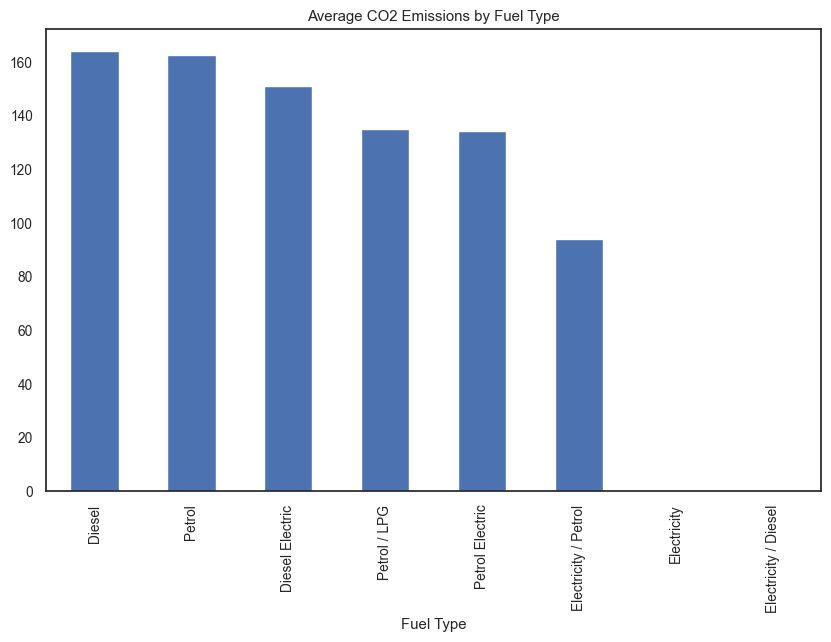

In [ ]:
data.groupby("Fuel Type")["WLTP CO2"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,6))
plt.title("Average CO2 Emissions by Fuel Type")

### The validation of datasets

*Fuel car data*


10-fold CV MSE scores: [148.34719952748313, 87.09378890071503, 11689.673431635883, 71.64909388638767, 48683.18442738336, 12731.164046163845, 78.1699874233327, 89.23377188624427, 154.502455495914, 98.94640656547571]
Mean MSE: 7383.196460886864


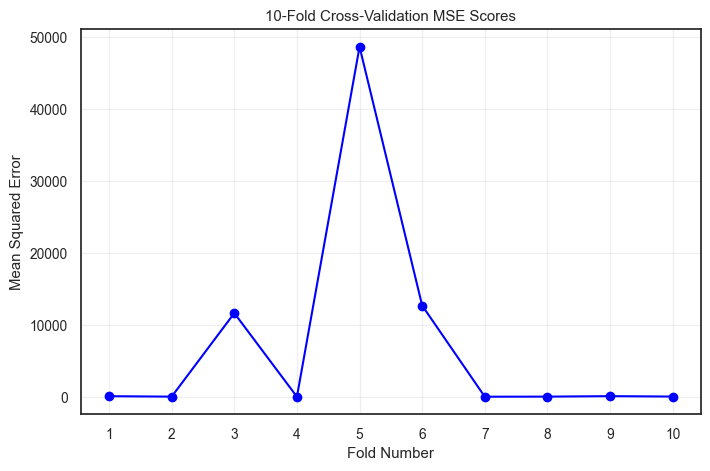

In [ ]:
# selected_features = [
#     "Engine Capacity", "Engine Power (PS)", 
#     "WLTP Imperial Combined"
# ]

# Prepare X and y
X = data_fuel.drop(columns=["WLTP CO2"])
y = data_fuel["WLTP CO2"]

# Remove categorical variables from X for linear regression
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
X = X.drop(columns=categorical_cols)

# Fill missing values in X with column means (numeric columns only)
X = X.fillna(X.mean(numeric_only=True))

# If any non-numeric columns remain with NaN after encoding, fill with a placeholder
X = X.fillna(0)

# Split into train (80%), temp (test + validation (20%)) 
##  Practical test splits 80-10-10 (from lecture 5)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)



# Split temp into test (10%) and validation (10%)
test_size = 1/2  # 10%% out of 20%
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=test_size, random_state=42)

# 10-fold cross-validation on training set
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    #Calculate MSE on the validation fold
    y_pred = model.predict(X_cv)
    mse = mean_squared_error(y_cv, y_pred)
    mse_scores.append(mse)

print("10-fold CV MSE scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-', color='blue')
plt.title('10-Fold Cross-Validation MSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('Mean Squared Error')
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

*Hybrid car data*

10-fold CV MSE scores: [90.04351467834931, 217.25922974420948, 653.0048931892718, 408.0462091699373, 195.45756065469595, 259.0590819777687, 325.88850483006286, 463.6133599184016, 114.27083011647225, 513.3183480050512]
Mean MSE: 323.99615322842203


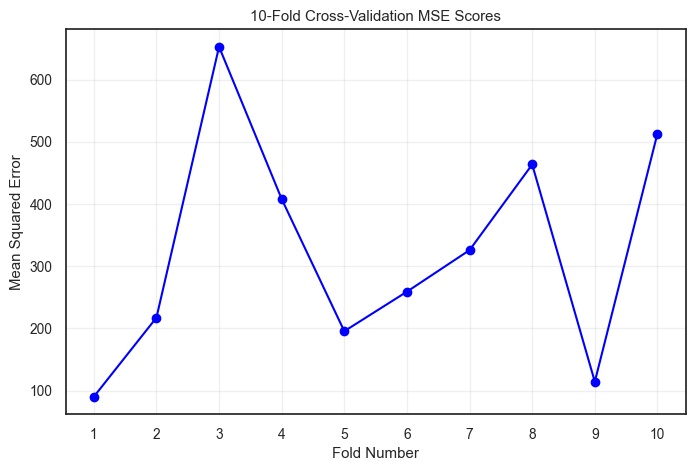

In [ ]:
# Prepare X and y
X = data_hybrid.drop(columns=["WLTP CO2"])
y = data_hybrid["WLTP CO2"]

# Remove categorical variables from X for linear regression
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
X = X.drop(columns=categorical_cols)

# Fill missing values in X with column means (numeric columns only)
X = X.fillna(X.mean(numeric_only=True))
# If any non-numeric columns remain with NaN after encoding, fill with a placeholder
X = X.fillna(0)

# Split into train (80%), temp (test + validation (20%)) 
##  Practical test splits 80-10-10 (from lecture 5)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temp into test (10%) and validation (10%)
test_size = 1/2  # 10%% out of 20%
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=test_size, random_state=42)

# 10-fold cross-validation on training set
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    #Calculate MSE on the validation fold
    y_pred = model.predict(X_cv)
    mse = mean_squared_error(y_cv, y_pred)
    mse_scores.append(mse)

print("10-fold CV MSE scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-', color='blue')
plt.title('10-Fold Cross-Validation MSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('Mean Squared Error')
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

In [ ]:
(Please ignore this part, I put here for reference to my work)
Here are some steps for statistical analysis with your dataset:
1. **Descriptive Statistics**:  
    Use `data.describe()` to get mean, median, std, min, max, and quartiles for numerical columns.

2. **Missing Data Analysis**:  
    Check missing values with `data.isnull().sum()`. Decide on imputation or removal.

3. **Correlation Analysis**:  
    Use `data.corr()` to find relationships between variables. Visualize with a heatmap (already done).

4. **Distribution Analysis**:  
    Plot histograms or boxplots for key variables to check their distributions and outliers.

5. **Group Comparisons**:  
    Use `groupby()` to compare statistics across categories (e.g., Fuel Type, Powertrain).

6. **Feature Selection**:  
    Identify highly correlated features (see your `top15_df`) and consider removing redundant ones.

7. **Regression/Classification Prep**:  
    Identify your target variable. If it's continuous, use regression; if categorical, use classification.

8. **Validation Strategy**:  
    Plan for cross-validation (e.g., KFold) to assess model performance.

9. **Data Visualization**:  
    Use scatter plots, pairplots, or bar charts to visualize relationships and trends.

Let me know which step you want to explore further or need code for.

SyntaxError: unterminated string literal (detected at line 22) (3425279247.py, line 22)

## Neural Network 